# Inspect Label Generation
This notebook validates binary and 3-class label generation on a small sample.

It is intentionally lightweight and uses only a few images.

## Load One Sample and Visualize Labels
Uses memory-mapped arrays to avoid large RAM usage, then renders one example for intuition.

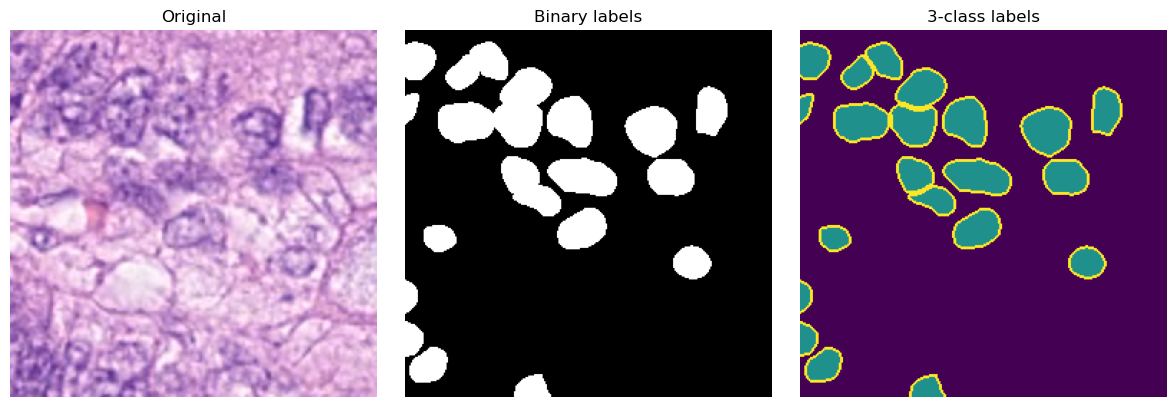

In [18]:
from pathlib import Path
import sys
from unittest.mock import MagicMock

# Make the repo importable even if the kernel starts in notebooks/.
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

# Staintools may import optional deps we do not need for this notebook.
sys.modules['spams'] = MagicMock()

import numpy as np
import matplotlib.pyplot as plt

from src.data.label_generator import generate_binary_labels, generate_3class_labels

fold = 1
images = np.load(
    f"../data/raw/Fold{fold}/images/fold{fold}/images.npy",
    mmap_mode="r",
    )
masks = np.load(
    f"../data/raw/Fold{fold}/masks/fold{fold}/masks.npy",
    mmap_mode="r",
    )

img = images[789].astype(np.uint8)
mask = masks[789]

binary_lbl = generate_binary_labels(mask)
three_lbl = generate_3class_labels(mask, erosion_radius=2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(binary_lbl, cmap="gray")
axes[1].set_title("Binary labels")
axes[1].axis("off")

axes[2].imshow(three_lbl, cmap="viridis")
axes[2].set_title("3-class labels")
axes[2].axis("off")
plt.tight_layout()

## Quick Sanity Stats
Prints class values and rough pixel fractions to confirm label balance.

In [19]:
import numpy as np

print("Binary unique values:", np.unique(binary_lbl))
print("3-class unique values:", np.unique(three_lbl))
print("Binary nucleus fraction:", binary_lbl.mean())
print("Interior fraction:", (three_lbl == 1).mean())
print("Boundary fraction:", (three_lbl == 2).mean())
print("Background fraction:", (three_lbl == 0).mean())

Binary unique values: [0 1]
3-class unique values: [0 1 2]
Binary nucleus fraction: 0.18328857421875
Interior fraction: 0.1381988525390625
Boundary fraction: 0.0450897216796875
Background fraction: 0.81671142578125


## Boundary Class Sensitivity (Erosion Radius)
Compares boundary thickness for several erosion radii and explains how touching nuclei are handled.

Touching nuclei note:
- Boundaries are generated by eroding each nucleus instance separately.
- This prevents merging boundaries at contact zones for different instances.
- If two nuclei truly touch, boundaries can still appear adjacent but remain separated by instance-wise erosion.


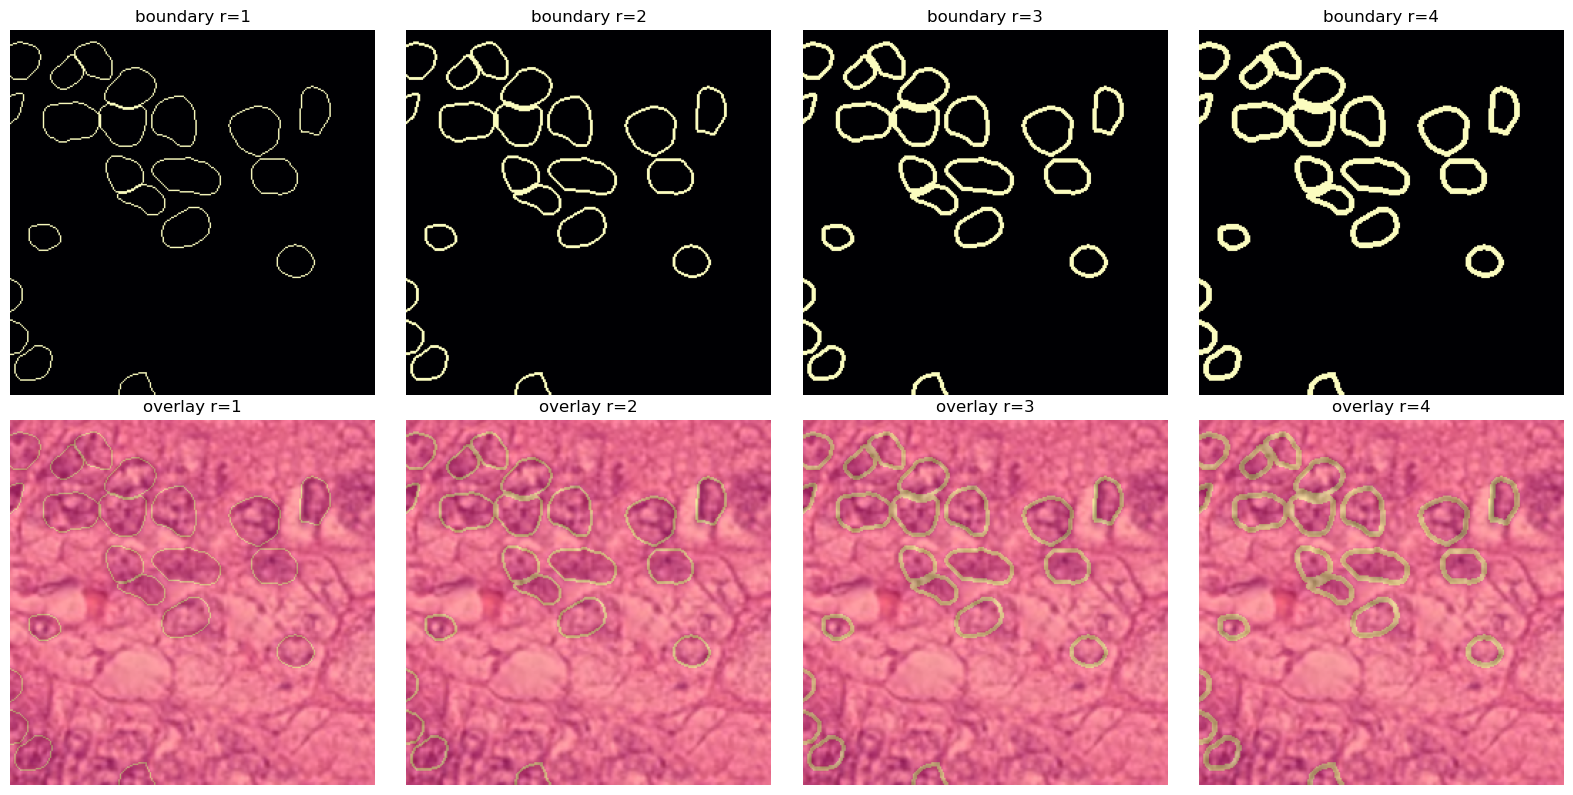

In [20]:
import numpy as np
import matplotlib.pyplot as plt

radii = [1, 2, 3, 4]
fig, axes = plt.subplots(2, len(radii), figsize=(4 * len(radii), 8))

for ax, r in zip(axes[0], radii):
    lbl = generate_3class_labels(mask, erosion_radius=r)
    boundary = (lbl == 2).astype(np.uint8)
    ax.imshow(boundary, cmap="magma")
    ax.set_title(f"boundary r={r}")
    ax.axis("off")

for ax, r in zip(axes[1], radii):
    lbl = generate_3class_labels(mask, erosion_radius=r)
    boundary = (lbl == 2)
    ax.imshow(img)
    ax.imshow(boundary, cmap="autumn", alpha=0.35)
    ax.set_title(f"overlay r={r}")
    ax.axis("off")

plt.tight_layout()

print("Touching nuclei note:")
print("- Boundaries are generated by eroding each nucleus instance separately.")
print("- This prevents merging boundaries at contact zones for different instances.")
print("- If two nuclei truly touch, boundaries can still appear adjacent but remain"
      " separated by instance-wise erosion.")